In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

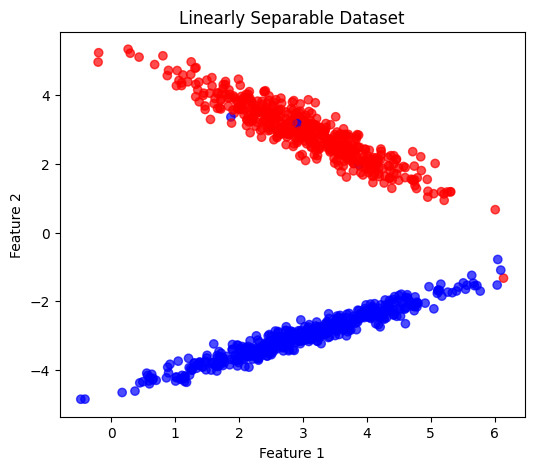

In [2]:
# -------------------------------
# (a) Create linearly separable dataset
# -------------------------------
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=3,
    random_state=42
)

# Convert labels from {0,1} → {-1,1}
y = np.where(y == 0, -1, 1)

# Plot dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', alpha=0.7)
plt.title("Linearly Separable Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [3]:
# -------------------------------
# Perceptron Class
# -------------------------------
class Perceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):
            for i in range(n_samples):
                xi = X[i]
                yi = y[i]

                linear_output = np.dot(xi, self.w) + self.b
                y_pred = np.sign(linear_output)

                if y_pred == 0:
                    y_pred = -1

                # Update rule
                if yi * y_pred <= 0:
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)

In [4]:
# -------------------------------
# Function to plot decision boundary
# -------------------------------
def plot_decision_boundary(X, y, model, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', alpha=0.6)

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contour(xx, yy, Z, levels=[0], colors='black')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

Accuracy (Clean Data): 0.995


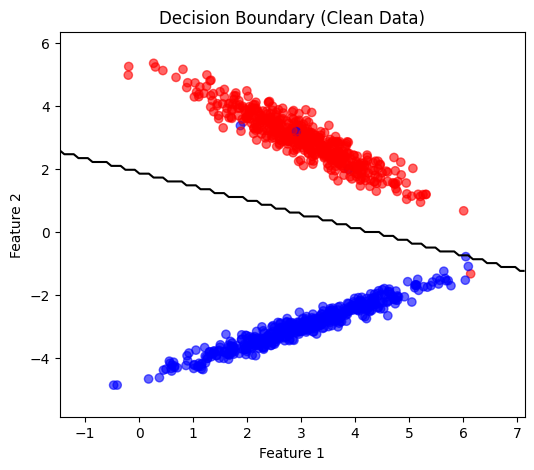

In [5]:
# -------------------------------
# (b) Train perceptron on clean data
# -------------------------------
model = Perceptron(lr=0.01, epochs=50)
model.fit(X, y)

pred = model.predict(X)
accuracy = np.mean(pred == y)

print("Accuracy (Clean Data):", accuracy)

plot_decision_boundary(X, y, model, "Decision Boundary (Clean Data)")

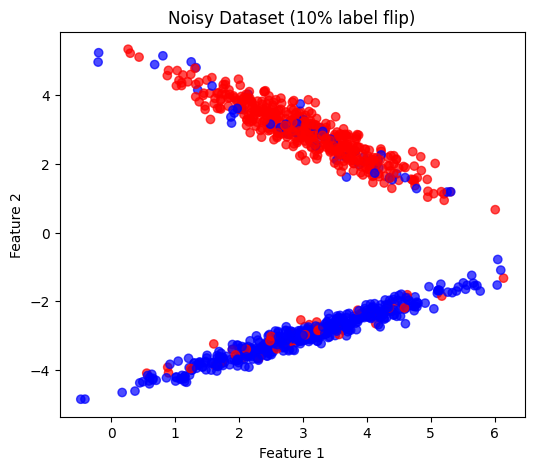

In [6]:
# -------------------------------
# (c) Add noise (10%)
# -------------------------------
y_noisy = np.copy(y)
n_flip = int(0.10 * len(y))

np.random.seed(42)
flip_idx = np.random.choice(len(y), n_flip, replace=False)
y_noisy[flip_idx] *= -1

# Plot noisy dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y_noisy, cmap='bwr', alpha=0.7)
plt.title("Noisy Dataset (10% label flip)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


Epochs: 10
Accuracy: 0.8950
Misclassifications: 105


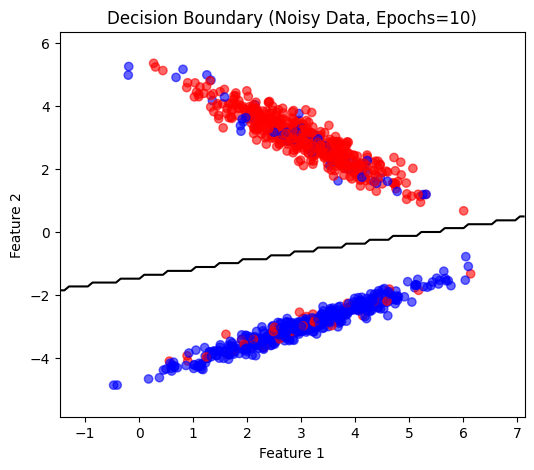


Epochs: 50
Accuracy: 0.7340
Misclassifications: 266


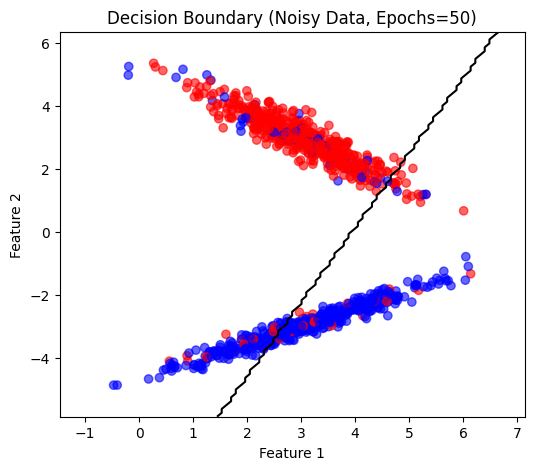


Epochs: 100
Accuracy: 0.5290
Misclassifications: 471


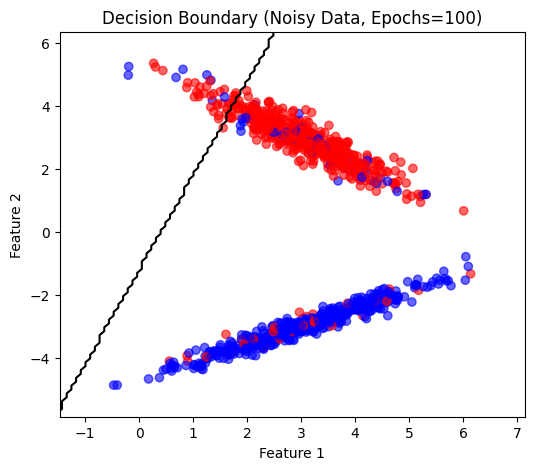

In [7]:
# -------------------------------
# Train with different iterations
# -------------------------------
epochs_list = [10, 50, 100]

for ep in epochs_list:
    model = Perceptron(lr=0.01, epochs=ep)
    model.fit(X, y_noisy)

    pred = model.predict(X)
    accuracy = np.mean(pred == y_noisy)
    mistakes = np.sum(pred != y_noisy)

    print(f"\nEpochs: {ep}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Misclassifications: {mistakes}")

    plot_decision_boundary(
        X, y_noisy, model,
        f"Decision Boundary (Noisy Data, Epochs={ep})"
    )